# Week 9 — Day 1 — Session 1
# What Is a Gradient?
## The Signal That Teaches a Neural Network

---

# 1. Learning Objectives

By the end of this session, students should be able to:

- Explain what a gradient means intuitively.
- Distinguish between **gradient direction** and **gradient magnitude**.
- Explain why gradient descent moves in the direction of $-\nabla L$.
- Interpret a partial derivative as sensitivity.
- Understand the basic idea behind the Chain Rule.
- Explain Backpropagation as a mechanism for transporting gradient information backward.
- Calculate simple gradients manually.
- Inspect gradients using PyTorch.
- Explain why gradients are the fundamental learning signal in neural networks.

---

# 2. The Central Question

> **How does a neural network know which weights to change?**

A neural network may contain thousands, millions, or even billions of parameters.

When the network makes a wrong prediction, we need to answer two questions:

1. **Which parameters should change?**
2. **In which direction should they change?**

The answer is:

> **The gradient tells us how the Loss changes when the parameters change.**

---

# Part 1 — Gradient
## The Signal That Teaches a Neural Network
> Suppose a neural network makes a prediction that is wrong. How can the network know which of its thousands of weights should change?
> Today we are going to understand the mechanism behind that answer.

---

# Derivative vs. Gradient

The simplest way to see the relationship:

## 1. One variable → Derivative

If Loss depends on one parameter:

$$
L(w)=(w-3)^2
$$

we calculate:

$$
\frac{dL}{dw}=2(w-3)
$$

The derivative tells us:

> **How does the Loss change when $w$ changes?**

---

## 2. Multiple variables → Partial Derivatives

Suppose:

$$
L(w_1,w_2)=w_1^2+2w_2^2
$$

We calculate a derivative for each parameter:

$$
\frac{\partial L}{\partial w_1}=2w_1
$$

$$
\frac{\partial L}{\partial w_2}=4w_2
$$

These are **partial derivatives**.

---

## 3. Collect Them → Gradient

We put all partial derivatives into a vector:

$$
\boxed{
\nabla L=
\begin{bmatrix}
\frac{\partial L}{\partial w_1}\\
\frac{\partial L}{\partial w_2}
\end{bmatrix}
}
$$

So:

```text
One parameter
      ↓
  Derivative
      ↓
Multiple parameters
      ↓
Partial derivatives
      ↓
Gradient vector
````

---

## 4. The Key Difference

|           | Derivative                      | Gradient                         |
| --------- | ------------------------------- | -------------------------------- |
| Variables | One                             | Multiple                         |
| Output    | Number                          | Vector                           |
| Meaning   | Rate of change in one direction | All partial derivatives together |

---

> **Derivative = change with respect to one variable.**
> **Gradient = all those derivatives collected into one vector.**



# Part 2 — The Big Picture

A neural network training loop can be simplified to:

```text
Input
  ↓
Neural Network
  ↓
Prediction
  ↓
Loss
  ↓
Gradient
  ↓
Update Weights
  ↓
Better Prediction
````

The critical transition is:

```text
Loss → Gradient → Weight Update
```

### Key Idea

> **Loss tells us how wrong we are.**
>
> **Gradient tells us how the Loss changes when we change the parameters.**

---

# Part 3 — Loss as a Landscape

<img src="img/lr_grad.png" width="600">

<img src="img/lr_grad.gif" width="600">

source: https://ml-visualized.com/chapter1/linear_regression

https://descent-visualisers.netlify.app/gd-visualizer/

## A Very Small Problem

Forget neural networks for a moment.

Consider:

$$
L(w)=(w-3)^2
$$

Our goal is:

$$
\min_w L(w)
$$


> What value of $w$ gives the smallest Loss?

Obviously:

$$
w=3
$$

because:

$$
L(3)=0
$$

But imagine that we **do not know** where the minimum is.

Ask:

> How could we find it?

---

## Look Around Us

Evaluate the Loss for several values of $w$:

| $w$ | $L(w)=(w-3)^2$ |
| --: | -------------: |
|   0 |              9 |
|   1 |              4 |
|   2 |              1 |
|   3 |              0 |
|   4 |              1 |
|   5 |              4 |
|   6 |              9 |

The Loss landscape looks like:

```text
Loss
 9 | ●                       ●
 8 |
 7 |
 6 |
 5 |
 4 |     ●               ●
 3 |
 2 |
 1 |         ●       ●
 0 |             ●
   +--------------------------
     0   1   2   3   4   5   6
                 w
```


> If we are currently at $w=5$, which direction should we move?
> How do we know how strongly we should move?

This leads to the derivative.

---

# Part 4 — What Is a Derivative?

## Derivative as Slope

For:

$$
L(w)=(w-3)^2
$$

the derivative is:

$$
\frac{dL}{dw}=2(w-3)
$$

At:

$$
w=5
$$

we get:

$$
\frac{dL}{dw}=2(5-3)=4
$$

So the local slope is:

$$
+4
$$

---

## Interpretation

A positive gradient means:

> Increasing $w$ will locally increase the Loss.

Therefore, to reduce the Loss, we should move in the opposite direction.

---

# Part 5 — The Gradient Is Not the Update

This distinction is extremely important.

Suppose:

$$
\frac{dL}{dw}=4
$$

The gradient is:

$$
g=4
$$

It does **not** mean:

$$
w \leftarrow w-4
$$

Instead:

$$
w_{\text{new}}
= w-\eta g
$$

where $\eta$ is the **learning rate**.

For example:

$$
\eta=0.1
$$

Then:

$$
w_{\text{new}}= 5-0.1(4)
= 4.6
$$

Therefore:

```text
Gradient
    ↓
Direction + sensitivity

Learning Rate
    ↓
Step size
```

---

# Part 6 — The Most Important Equation of Today

## Gradient Descent

For one parameter:

$$
\boxed{
w_{\text{new}}=
w-\eta\frac{dL}{dw}
}
$$

For many parameters:

$$
\boxed{
\mathbf{w}_{\text{new}}=
\mathbf{w} - \eta\nabla L
}
$$

Where:

* $\mathbf{w}$ = model parameters
* $L$ = Loss
* $\nabla L$ = gradient
* $\eta$ = learning rate

---

# Part 7 — Why the Minus Sign?

This is one of the most important conceptual points.

The gradient points toward:

> **The direction of steepest local increase in Loss.**

But our goal is to decrease Loss.

Therefore we move in:

$$
-\nabla L
$$

which points toward the direction of steepest local decrease.

### Remember

> **Gradient = uphill**

> **Negative gradient = downhill**

---

# Part 8 — Mountain Analogy

Imagine standing on a mountain.

```text
                 Loss
                  ↑
                 /\
                /  \
               /    \
              /  ●   \
             /   ↓    \
            /    ↓     \
           /_____↓______\
```

The gradient tells you:

> Which direction goes uphill most steeply?

But during training we want to go downhill.

Therefore:

$$
\boxed{\text{Training moves approximately in }-\nabla L}
$$

---

# Part 9 — Gradient Magnitude and Direction

## Two Important Pieces of Information

A gradient contains two important types of information.

### Direction

> Which way should we move?

### Magnitude

> How sensitive is the Loss to the parameter?

For example:

$$
g=0.01
$$

indicates relatively small local sensitivity.

While:

$$
g=10
$$

indicates much stronger local sensitivity.

### Important Caveat

Gradient magnitude is **not simply "parameter importance."**

It is a local measure of how sensitive the Loss is to a parameter.

---

# Part 10 — From Derivative to Gradient

## One Parameter vs. Many Parameters

Real neural networks contain many parameters.

Suppose:

$$
L=L(w_1,w_2)
$$

We need:

$$
\frac{\partial L}{\partial w_1}
$$

and:

$$
\frac{\partial L}{\partial w_2}
$$

We combine them into a vector:

$$
\nabla L=
\begin{bmatrix}
\frac{\partial L}{\partial w_1}\
\frac{\partial L}{\partial w_2}
\end{bmatrix}
$$

This is the **gradient vector**.

---

# Part 11 — A Simple 2D Example

Consider:

$$
L(w_1,w_2)=
w_1^2+2w_2^2
$$

The partial derivatives are:

$$
\frac{\partial L}{\partial w_1}=2w_1
$$

$$
\frac{\partial L}{\partial w_2}=4w_2
$$

Therefore:

$$
\nabla L=
\begin{bmatrix}
2w_1\
4w_2
\end{bmatrix}
$$

Suppose:

$$
w_1=2,\qquad w_2=1
$$

Then:

$$
\nabla L=
\begin{bmatrix}
4\
4
\end{bmatrix}
$$

Therefore:

$$
-\nabla L=
\begin{bmatrix}
-4\
-4
\end{bmatrix}
$$

So the parameters should move toward smaller values.

---

# Part 12 — Loss Landscape Visualization

A useful visualization is a contour plot of:

$$
L(w_1,w_2)=w_1^2+2w_2^2
$$

Current point:
w1 = 2.0
w2 = 1.0

Gradient:
dL/dw1 = 4.0
dL/dw2 = 4.0


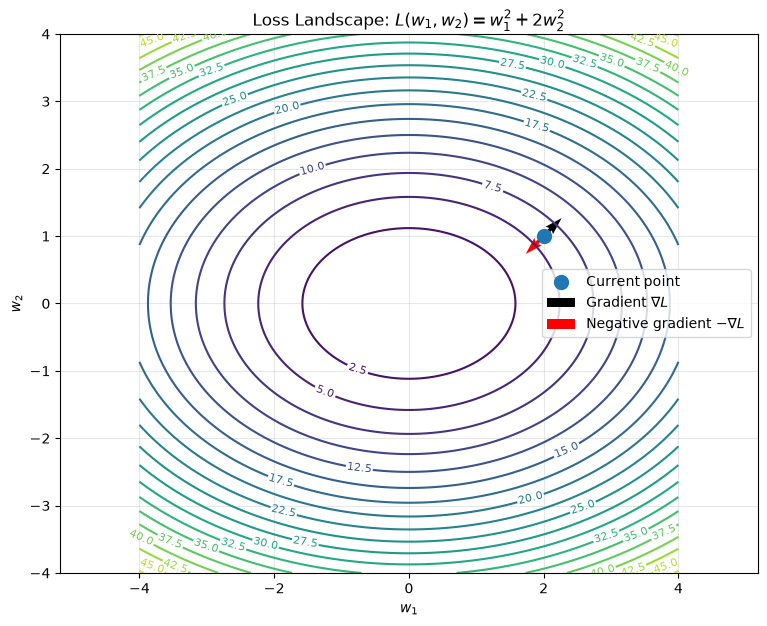

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Loss function
# L(w1, w2) = w1^2 + 2*w2^2
# --------------------------------------------------

def loss(w1, w2):
    return w1**2 + 2*w2**2


# --------------------------------------------------
# Gradient
#
# ∂L/∂w1 = 2w1
# ∂L/∂w2 = 4w2
# --------------------------------------------------

def gradient(w1, w2):
    dw1 = 2 * w1
    dw2 = 4 * w2
    return np.array([dw1, dw2])


# --------------------------------------------------
# Create the loss landscape
# --------------------------------------------------

w1 = np.linspace(-4, 4, 300)
w2 = np.linspace(-4, 4, 300)

W1, W2 = np.meshgrid(w1, w2)

L = loss(W1, W2)


# --------------------------------------------------
# Plot contour
# --------------------------------------------------

plt.figure(figsize=(9, 7))

contours = plt.contour(W1, W2, L, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("$w_1$")
plt.ylabel("$w_2$")
plt.title(r"Loss Landscape: $L(w_1,w_2)=w_1^2+2w_2^2$")


# --------------------------------------------------
# Choose a current point
# --------------------------------------------------

point = np.array([2.0, 1.0])

w1_current, w2_current = point

# Calculate gradient at this point
g = gradient(w1_current, w2_current)

print("Current point:")
print(f"w1 = {w1_current}")
print(f"w2 = {w2_current}")

print("\nGradient:")
print(f"dL/dw1 = {g[0]}")
print(f"dL/dw2 = {g[1]}")


# --------------------------------------------------
# Plot current point
# --------------------------------------------------

plt.scatter(
    w1_current,
    w2_current,
    s=100,
    zorder=5,
    label="Current point"
)


# --------------------------------------------------
# Plot gradient direction
#
# Gradient points uphill.
# --------------------------------------------------

plt.quiver(
    w1_current,
    w2_current,
    g[0],
    g[1],
    angles="xy",
    scale_units="xy",
    scale=15,
    width=0.005,
    label="Gradient $\\nabla L$"
)


# --------------------------------------------------
# Plot negative gradient direction
#
# Negative gradient points downhill.
# --------------------------------------------------

plt.quiver(
    w1_current,
    w2_current,
    -g[0],
    -g[1],
    angles="xy",
    scale_units="xy",
    scale=15,
    width=0.005,
    color='red',
    label="Negative gradient $-\\nabla L$"
)


plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

* Each point represents a parameter configuration.
* Each point has a Loss value.
* The gradient depends on our current position.
* The negative gradient indicates a downhill direction.

### Question


> If we move to a different point in the landscape, will the gradient remain the same?

Expected answer:

> No.

This establishes an important idea:

> **The gradient is local.**

---

# Part 13 — Gradient Descent Numerically

## Numerical Example

Return to:

$$
L(w)=(w-3)^2
$$

We have:

$$
\frac{dL}{dw}=2(w-3)
$$

Start with:

$$
w_0=6
$$

and:

$$
\eta=0.2
$$

---

## Step 1

$$
g_0=2(6-3)=6
$$

Update:

$$
w_1=6-0.2(6)=4.8
$$

---

## Step 2

$$
g_1=2(4.8-3)=3.6
$$

$$
w_2=4.8-0.2(3.6)=4.08
$$

---

## Step 3

$$
g_2=2(4.08-3)=2.16
$$

$$
w_3=4.08-0.2(2.16)=3.648
$$

We are approaching:

$$
w=3
$$

---

# Part 14 — Observe the Learning Process

| Step |   $w$ | Gradient |  Loss |
| ---: | ----: | -------: | ----: |
|    0 | 6.000 |    6.000 | 9.000 |
|    1 | 4.800 |    3.600 | 3.240 |
|    2 | 4.080 |    2.160 | 1.166 |
|    3 | 3.648 |    1.296 | 0.420 |
|    4 | 3.389 |    0.778 | 0.151 |
|    5 | 3.233 |    0.467 | 0.054 |

### Ask Students

What do you notice?

Expected observations:

* $w$ approaches 3.
* Loss decreases.
* Gradient magnitude decreases.
* Steps become smaller.

This observation will become important when we discuss deep-network gradient problems.

---

Step         w1         w2       dL/dw1       dL/dw2       Loss
----------------------------------------------------------------
   0      4.000      3.000        8.000       12.000     34.000
   1      3.200      1.800        6.400        7.200     16.720
   2      2.560      1.080        5.120        4.320      8.886
   3      2.048      0.648        4.096        2.592      5.034
   4      1.638      0.389        3.277        1.555      2.987
   5      1.311      0.233        2.621        0.933      1.827
   6      1.049      0.140        2.097        0.560      1.139
   7      0.839      0.084        1.678        0.336      0.718


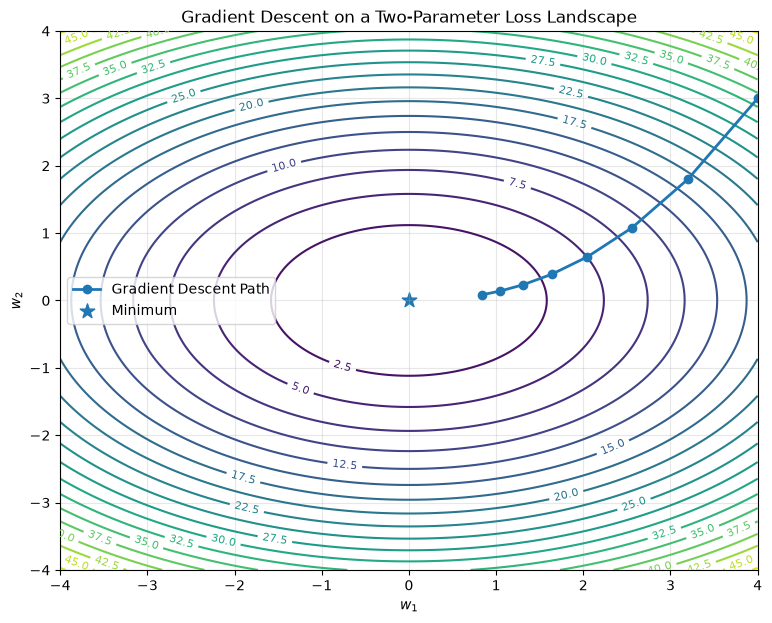

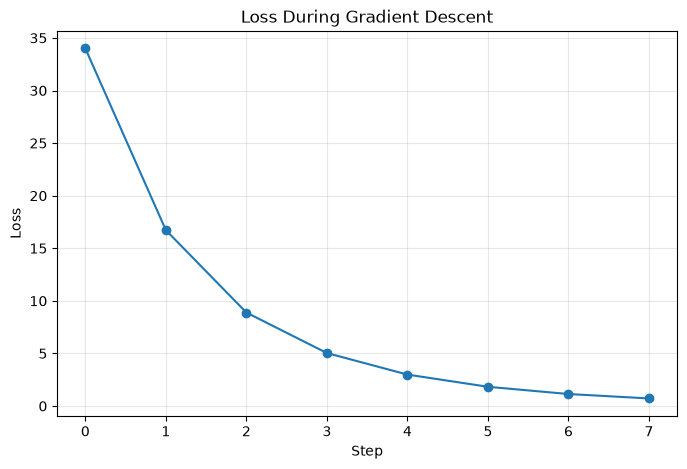

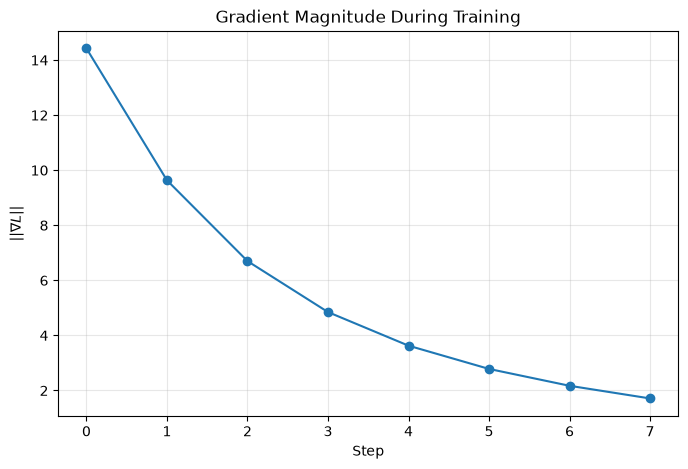

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Two-Parameter Gradient Descent
#
# Loss:
#     L(w1, w2) = w1^2 + 2*w2^2
#
# Gradients:
#     dL/dw1 = 2*w1
#     dL/dw2 = 4*w2
# ============================================================

def loss(w1, w2):
    return w1**2 + 2 * w2**2


def gradient(w1, w2):
    dw1 = 2 * w1
    dw2 = 4 * w2
    return np.array([dw1, dw2])


# ------------------------------------------------------------
# Gradient Descent settings
# ------------------------------------------------------------

w1 = 4.0
w2 = 3.0

learning_rate = 0.1
n_steps = 8

history = []


# ------------------------------------------------------------
# Gradient Descent
# ------------------------------------------------------------

for step in range(n_steps):

    current_loss = loss(w1, w2)
    grad = gradient(w1, w2)

    history.append(
        (step, w1, w2, grad[0], grad[1], current_loss)
    )

    # Update both parameters
    w1 = w1 - learning_rate * grad[0]
    w2 = w2 - learning_rate * grad[1]


# ------------------------------------------------------------
# Print learning process
# ------------------------------------------------------------

print(
    f"{'Step':>4} "
    f"{'w1':>10} "
    f"{'w2':>10} "
    f"{'dL/dw1':>12} "
    f"{'dL/dw2':>12} "
    f"{'Loss':>10}"
)

print("-" * 64)

for step, w1, w2, dw1, dw2, current_loss in history:

    print(
        f"{step:>4} "
        f"{w1:>10.3f} "
        f"{w2:>10.3f} "
        f"{dw1:>12.3f} "
        f"{dw2:>12.3f} "
        f"{current_loss:>10.3f}"
    )


# ============================================================
# Visualization 1: Parameter trajectory on the Loss landscape
# ============================================================

w1_values = np.linspace(-4, 4, 300)
w2_values = np.linspace(-4, 4, 300)

W1, W2 = np.meshgrid(w1_values, w2_values)

L = loss(W1, W2)

plt.figure(figsize=(9, 7))

contours = plt.contour(W1, W2, L, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

# Extract trajectory
trajectory_w1 = [row[1] for row in history]
trajectory_w2 = [row[2] for row in history]

plt.plot(
    trajectory_w1,
    trajectory_w2,
    marker="o",
    linewidth=2,
    label="Gradient Descent Path"
)

# Mark the optimum
plt.scatter(
    0,
    0,
    s=120,
    marker="*",
    label="Minimum"
)

plt.xlabel("$w_1$")
plt.ylabel("$w_2$")
plt.title("Gradient Descent on a Two-Parameter Loss Landscape")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# Visualization 2: Loss over training steps
# ============================================================

steps = [row[0] for row in history]
losses = [row[5] for row in history]

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    losses,
    marker="o"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss During Gradient Descent")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# Visualization 3: Gradient magnitude
# ============================================================

gradients_w1 = [row[3] for row in history]
gradients_w2 = [row[4] for row in history]

gradient_magnitude = np.sqrt(
    np.array(gradients_w1)**2 +
    np.array(gradients_w2)**2
)

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    gradient_magnitude,
    marker="o"
)

plt.xlabel("Step")
plt.ylabel("$||\\nabla L||$")
plt.title("Gradient Magnitude During Training")

plt.grid(True, alpha=0.3)
plt.show()

# Part 15 — Python: Gradient Descent From Scratch

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def loss(w):
    return (w - 3) ** 2

def gradient(w):
    return 2 * (w - 3)


w = 6.0
learning_rate = 0.2

history = [w]

for step in range(20):
    g = gradient(w)
    w = w - learning_rate * g
    history.append(w)

print("Final w:", w)
print("Final loss:", loss(w))


Final w: 3.000109684753202
Final loss: 1.2030745084947019e-08


# Part 16 — Visualize Gradient Descent

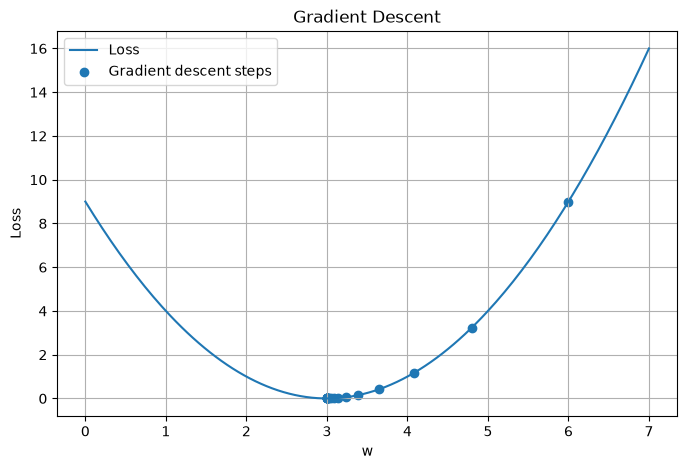

In [13]:
ws = np.linspace(0, 7, 200)
losses = loss(ws)

plt.figure(figsize=(8, 5))

plt.plot(ws, losses, label="Loss")

history = np.array(history)

plt.scatter(
    history,
    loss(history),
    label="Gradient descent steps"
)

plt.xlabel("w")
plt.ylabel("Loss")
plt.title("Gradient Descent")
plt.legend()
plt.grid(True)

plt.show()

### Question

Point to each dot and ask:

> What information did the model use to decide where the next dot should be?

Answer:

$$
\nabla L
$$

---

# Part 17 — Class Exercise

## Exercise 1: Predict the Next Step

Given:

$$
L(w)=(w-3)^2
$$

Current:

$$
w=5
$$

Learning rate:

$$
\eta=0.1
$$

### Questions

1. Calculate the gradient.
2. Should $w$ increase or decrease?
3. Calculate the new $w$.
4. Calculate the new Loss.

### Solution

Gradient:

$$
g=2(5-3)=4
$$

Update:

$$
w_{\text{new}}=
 5-0.1(4) = 4.6
$$

Old Loss:

$$
L(5)=4
$$

New Loss:

$$
L(4.6)=2.56
$$

### Key Observation

The update moved the parameter toward a lower Loss.

---

# Part 18 — Why Do We Need the Chain Rule?

## A More Realistic Model

Now consider a single neuron:

$$
\hat y=wx+b
$$

with Mean Squared Error:

$$
L=(\hat y-y)^2
$$

Substitute:

$$
L=(wx+b-y)^2
$$

Now ask:

> How does changing $w$ affect the Loss?

We need the Chain Rule.

---

# Part 19 — The Dependency Path

The dependency is:

```text
w
↓
ŷ
↓
L
```

To calculate:

$$
\frac{\partial L}{\partial w}
$$

we follow this path backward.

Therefore:

$$
\boxed{
\frac{\partial L}{\partial w}=
\frac{\partial L}{\partial \hat y}
\frac{\partial \hat y}{\partial w}
}
$$

This is the fundamental idea behind Backpropagation.

---

# Part 20 — Numerical Chain Rule Example

Suppose:

$$
x=2
$$

$$
w=3
$$

$$
b=1
$$

$$
y=10
$$

Prediction:

$$
\hat y=wx+b
$$

Therefore:

$$
\hat y=3(2)+1=7
$$

Loss:

$$
L=(7-10)^2=9
$$

Now calculate the gradient.

---

## Step 1 — Gradient of Loss With Respect to Prediction

$$
\frac{\partial L}{\partial \hat y}=
2(\hat y-y)
$$

Therefore:

$$
\frac{\partial L}{\partial\hat y}=
2(7-10) = -6
$$

---

## Step 2 — Gradient of Prediction With Respect to Weight

Since:

$$
\hat y=wx+b
$$

we have:

$$
\frac{\partial\hat y}{\partial w}=x
$$

Therefore:

$$
\frac{\partial\hat y}{\partial w}=2
$$

---

## Step 3 — Apply the Chain Rule

$$
\frac{\partial L}{\partial w}=
(-6)(2)=
-12
$$

Therefore:

$$
\boxed{
\frac{\partial L}{\partial w}=-12
}
$$

---

# Part 21 — Interpret the Result

We obtained:

$$
\frac{\partial L}{\partial w}=-12
$$

What does this mean?

It means:

> Increasing $w$ slightly will locally decrease the Loss.

Therefore gradient descent performs:

$$
w_{\text{new}}=
w-\eta(-12)
$$

So:

$$
w_{\text{new}}>w
$$

### Important Rule

If:

$$
\frac{\partial L}{\partial w}>0
$$

then decrease $w$.

If:

$$
\frac{\partial L}{\partial w}<0
$$

then increase $w$.

---

# Part 22 — Backpropagation

## Chain Rule as a Dependency Map

Think of the network as a sequence of transformations:

```text
Parameter
   ↓
Layer
   ↓
Activation
   ↓
Next Layer
   ↓
Prediction
   ↓
Loss
```

The gradient travels in the opposite direction:

```text
Loss
↑
Prediction
↑
Layer
↑
Activation
↑
Layer
↑
Parameter
```

### Key Idea

> **Backpropagation is the systematic application of the Chain Rule to compute how the Loss depends on every parameter.**

---

# Part 23 — From One Neuron to a Neural Network

Consider:

```text
Input
  ↓
Linear Layer
  ↓
Activation
  ↓
Linear Layer
  ↓
Prediction
  ↓
Loss
```

Forward pass:

```text
x
 ↓
z₁
 ↓
a₁
 ↓
z₂
 ↓
ŷ
 ↓
L
```

Backward pass:

```text
L
↓
ŷ
↓
z₂
↓
a₁
↓
z₁
↓
weights
```

The backward pass computes the gradient of the Loss with respect to each parameter.

---

# Part 24 — The Big Insight


> **What does a neural network actually learn?**

answer:

> It learns parameter values that reduce the Loss.


> **How does it know how to change those parameters?**

answer:

> Gradients.


> **How does it calculate gradients in a deep network?**

answer:

> Backpropagation using the Chain Rule.

---

# Part 25 — PyTorch Autograd

## Let PyTorch Calculate the Gradient

Reproduce the single-neuron example.

In [1]:


import torch

x = torch.tensor(2.0)
y = torch.tensor(10.0)

w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y_hat = w * x + b

loss = (y_hat - y) ** 2

loss.backward()

print("Prediction:", y_hat.item())
print("Loss:", loss.item())
print("dL/dw:", w.grad.item())
print("dL/db:", b.grad.item())

Prediction: 7.0
Loss: 9.0
dL/dw: -12.0
dL/db: -6.0


# Part 26 — What Did PyTorch Do?

When we call:

```python
loss.backward()
```

PyTorch applies the Chain Rule through the computation graph.

Conceptually:

```text
w ───────→ ŷ ───────→ Loss
           ↑
           │
           x
```

After:

```python
loss.backward()
```

we can access:

In [3]:
print(f"gradient with respect to w: {w.grad}")
print(f"gradient with respect to b: {b.grad}")


gradient with respect to w: -12.0
gradient with respect to b: -6.0


which represent:

$$
\frac{\partial L}{\partial w}
$$

and:

$$
\frac{\partial L}{\partial b}
$$

---

# Part 27 — The Computation Graph

The computation can be visualized as:

```text
       w
       │
       ▼
      wx
       │
       ▼
    wx + b ─────→ ŷ
                    │
                    ▼
                  ŷ - y
                    │
                    ▼
                  Loss
```

### Forward Pass

Compute:

```text
Input → Prediction → Loss
```

### Backward Pass

Compute:

```text
Loss → Gradients
```

---

# Part 28 — Manual Weight Update

## One Learning Step

We have:

$$
w=3
$$

and:

$$
\frac{\partial L}{\partial w}=-12
$$

With:

$$
\eta=0.1
$$

the update is:

$$
w_{\text{new}}=
3-0.1(-12)
$$

Therefore:

$$
\boxed{w_{\text{new}}=4.2}
$$

The complete process is:

```text
Gradient = -12
     ↓
Move opposite the gradient
     ↓
w increases
     ↓
Prediction increases
     ↓
Prediction moves toward y = 10
     ↓
Loss decreases
```

This is learning.

---

# Part 29 — Complete PyTorch Training Loop

 Step       Loss          w          b      dL/dw      dL/db
-----------------------------------------------------------------
    0    57.0000     0.0000     0.0000   -50.0000   -14.0000
   10     0.2865     1.9688     0.5602    -3.3254    -1.0669
   20     0.0284     2.0977     0.6102    -0.1898    -0.1935
   30     0.0255     2.1030     0.6256     0.0199    -0.1307
   40     0.0238     2.1002     0.6382     0.0329    -0.1226
   50     0.0223     2.0969     0.6503     0.0327    -0.1183
   60     0.0208     2.0936     0.6619     0.0317    -0.1143
   70     0.0194     2.0905     0.6732     0.0306    -0.1105
   80     0.0182     2.0875     0.6841     0.0296    -0.1068
   90     0.0170     2.0846     0.6946     0.0286    -0.1033

Final parameters:
w = 2.0818
b = 0.7048

Learned model:
y = 2.0818x + 0.7048


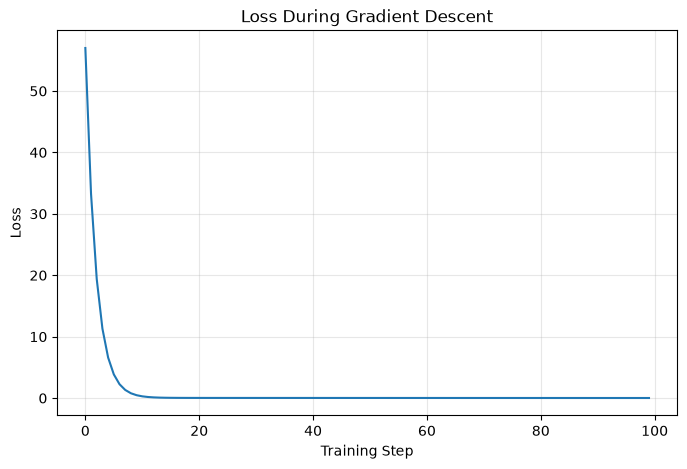

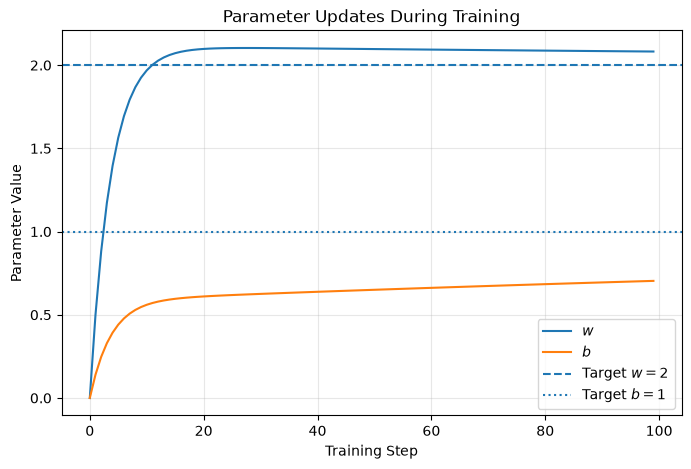

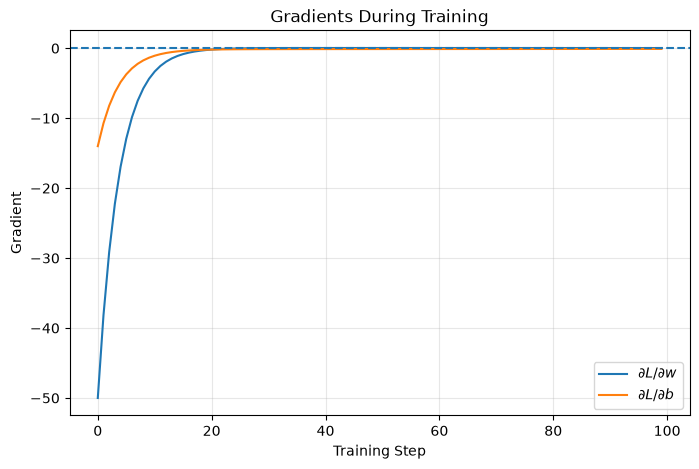

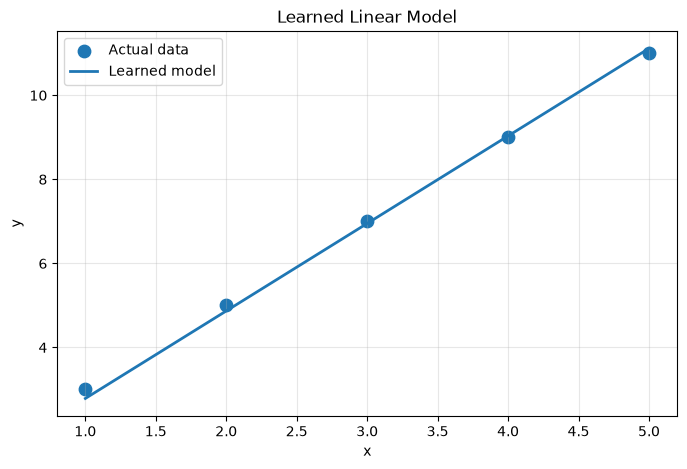

In [15]:
# Part 29 — Complete PyTorch Training Loop
#
# Goal:
# Understand what PyTorch actually does during
# forward pass → loss → backward pass → gradient descent
#
# Model:
#     y_hat = w*x + b
#
# Dataset:
#     y = 2x + 1
#
# We will learn w ≈ 2 and b ≈ 1


import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. Create a small dataset
# ============================================================

x = torch.tensor(
    [1.0, 2.0, 3.0, 4.0, 5.0]
)

y = torch.tensor(
    [3.0, 5.0, 7.0, 9.0, 11.0]
)


# ============================================================
# 2. Initialize parameters
# ============================================================

w = torch.tensor(
    0.0,
    requires_grad=True
)

b = torch.tensor(
    0.0,
    requires_grad=True
)

learning_rate = 0.01
n_steps = 100


# Store training history
history = {
    "step": [],
    "loss": [],
    "w": [],
    "b": [],
    "dw": [],
    "db": [],
}


# ============================================================
# 3. Training loop
# ============================================================

for step in range(n_steps):

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------

    y_hat = w * x + b

    # Mean Squared Error
    loss = torch.mean((y_hat - y) ** 2)


    # --------------------------------------------------------
    # Backward pass
    # --------------------------------------------------------

    loss.backward()


    # At this point PyTorch has calculated:
    #
    #     w.grad = dL/dw
    #     b.grad = dL/db
    #
    # Together:
    #
    #     gradient =
    #     [dL/dw, dL/db]


    # Save values BEFORE updating parameters
    history["step"].append(step)
    history["loss"].append(loss.item())
    history["w"].append(w.item())
    history["b"].append(b.item())
    history["dw"].append(w.grad.item())
    history["db"].append(b.grad.item())


    # --------------------------------------------------------
    # Gradient descent update
    # --------------------------------------------------------

    with torch.no_grad():

        w -= learning_rate * w.grad
        b -= learning_rate * b.grad


    # --------------------------------------------------------
    # Clear gradients
    # --------------------------------------------------------
    #
    # PyTorch accumulates gradients by default.
    # We need to reset them before the next iteration.

    w.grad.zero_()
    b.grad.zero_()


# ============================================================
# 4. Display the training process
# ============================================================

print(
    f"{'Step':>5} "
    f"{'Loss':>10} "
    f"{'w':>10} "
    f"{'b':>10} "
    f"{'dL/dw':>10} "
    f"{'dL/db':>10}"
)

print("-" * 65)

for i in range(0, n_steps, 10):

    print(
        f"{history['step'][i]:5d} "
        f"{history['loss'][i]:10.4f} "
        f"{history['w'][i]:10.4f} "
        f"{history['b'][i]:10.4f} "
        f"{history['dw'][i]:10.4f} "
        f"{history['db'][i]:10.4f}"
    )


# ============================================================
# 5. Final learned parameters
# ============================================================

print("\nFinal parameters:")
print(f"w = {w.item():.4f}")
print(f"b = {b.item():.4f}")

print("\nLearned model:")
print(f"y = {w.item():.4f}x + {b.item():.4f}")


# ============================================================
# 6. Visualize Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history["step"],
    history["loss"]
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss During Gradient Descent")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 7. Visualize parameters
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history["step"],
    history["w"],
    label="$w$"
)

plt.plot(
    history["step"],
    history["b"],
    label="$b$"
)

plt.axhline(
    2,
    linestyle="--",
    label="Target $w=2$"
)

plt.axhline(
    1,
    linestyle=":",
    label="Target $b=1$"
)

plt.xlabel("Training Step")
plt.ylabel("Parameter Value")
plt.title("Parameter Updates During Training")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 8. Visualize the gradients
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history["step"],
    history["dw"],
    label="$\\partial L / \\partial w$"
)

plt.plot(
    history["step"],
    history["db"],
    label="$\\partial L / \\partial b$"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Training Step")
plt.ylabel("Gradient")
plt.title("Gradients During Training")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 9. Compare predictions with actual data
# ============================================================

with torch.no_grad():

    predictions = w * x + b


plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    s=80,
    label="Actual data"
)

plt.plot(
    x,
    predictions,
    linewidth=2,
    label="Learned model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Learned Linear Model")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# Part 30 — The Training Loop

Students should recognize this pattern:

```text
        ┌──────────────┐
        │ Forward Pass │
        └──────┬───────┘
               ↓
             Loss
               ↓
        ┌───────────────┐
        │ Backward Pass │
        └──────┬────────┘
               ↓
           Gradients
               ↓
        ┌───────────────┐
        │ Update Weights│
        └──────┬────────┘
               ↓
          Repeat...
```

The three essential operations are conceptually:

```python
loss = ...
loss.backward()
optimizer.step()
```

---

# Part 31 — What If the Gradient Is Zero?

Suppose:

$$
\nabla L=0
$$

Then:

$$
w_{\text{new}}=
w-\eta(0)w
$$

No update occurs.

### Important

A zero gradient means:

> **The local slope is zero.**

It does **not automatically mean**:

> "The network has found the global optimum."

A point with zero gradient may be:

* a local minimum,
* a local maximum,
* or a saddle point.

We will return to these ideas later.

---

# Part 32 — Exercise 2

Consider:

$$
L(w)=(w-5)^2
$$

Current:

$$
w=2
$$

Learning rate:

$$
\eta=0.1
$$

### Questions

1. Calculate the gradient.
2. Should $w$ increase or decrease?
3. Calculate the new $w$.
4. Does the new point have a smaller Loss?

### Solution

$$
\frac{dL}{dw}=2(w-5)
$$

Therefore:

$$
g=2(2-5)=-6
$$

Update:

$$
w_{\text{new}}
=

2-0.1(-6)
$$

$$
\boxed{w_{\text{new}}=2.6}
$$

The weight increases because the gradient is negative.

---

# Part 33 — Gradient Is Local

## Local Approximation

For a small parameter change:

$$
\Delta L
\approx
\nabla L^T\Delta\mathbf{w}
$$

For one parameter:

$$
\Delta L
\approx
\frac{\partial L}{\partial w}\Delta w
$$

This means:

> The gradient tells us how the Loss is expected to change for a small parameter change.

This is why gradient information is useful for optimization.

---

# Part 34 — Why "Local" Matters

The gradient describes the Loss landscape **near the current point**.

It does not tell us:

* the entire Loss surface,
* the global minimum,
* the future trajectory,
* or what happens after a very large parameter change.

It tells us:

> **What is the local direction of change right here?**

---

# Part 35 — The Central Mental Model

```text
                    LOSS
                      │
                      │
                "How wrong?"
                      │
                      ▼
                  GRADIENT
                      │
             "How should I change?"
                      │
                      ▼
               - GRADIENT
                      │
                "Move this way"
                      │
                      ▼
               LEARNING RATE
                      │
                "How far?"
                      │
                      ▼
                 NEW WEIGHTS
```

---

# Part 36 — The Four Concepts

Students should now understand these four concepts:

### 1. Loss

> How wrong is the model?

### 2. Gradient

> How does the Loss change when parameters change?

### 3. Negative Gradient

> Which direction locally reduces the Loss?

### 4. Learning Rate

> How large should the update be?

---

# Part 37 — Final Conceptual Exercise

## Think-Pair-Share

Suppose:

$$
\nabla L=
\begin{bmatrix}
10\
-2\
0.1
\end{bmatrix}
$$

Ask students:

1. Which parameter has the largest local sensitivity?
2. Which parameter should increase?
3. Which parameters should decrease?
4. What happens if we double the learning rate?

### Expected Reasoning

For $w_1$:

$$
g_1=10
$$

Therefore:

$$
w_1 \downarrow
$$

For $w_2$:

$$
g_2=-2
$$

Therefore:

$$
w_2 \uparrow
$$

For $w_3$:

$$
g_3=0.1
$$

Therefore:

$$
w_3 \downarrow
$$

but only by a relatively small amount for the same learning rate.

---

# Part 38 — Summary

## What Have We Learned?

### 1. Loss

Measures how wrong the prediction is.

### 2. Derivative

Measures local sensitivity to one parameter.

### 3. Gradient

Collects these sensitivities for all parameters.

### 4. Negative Gradient

Points toward local decrease of Loss.

### 5. Learning Rate

Controls the size of the update.

### 6. Backpropagation

Uses the Chain Rule to calculate gradients throughout the network.

---

# Part 39 — The One Sentence Students Should Remember

> **A gradient tells us how the Loss changes when we change the parameters; backpropagation computes those gradients, and gradient descent uses them to move the parameters toward lower Loss.**

---

# Part 40 — Exit Ticket

Answer these questions without looking at the notes.

### Question 1

If:

$$
\frac{\partial L}{\partial w}>0
$$

should we increase or decrease $w$?

**Answer:** Decrease $w$.

---

### Question 2

What does gradient magnitude tell us?

**Expected answer:**

> It tells us the local sensitivity of the Loss to parameter changes.

---

### Question 3

Complete:

> **Backpropagation is ____________.**

Expected:

> **An efficient application of the Chain Rule for computing gradients throughout a neural network.**

---

# Part 41 — Preview of Session 2

End the session with this question:

> **If the gradient is the learning signal, what happens when that signal becomes extremely small as it travels through many layers?**

Show:

```text
Loss
 ↓
Layer 10    Gradient = 1.00
 ↓
Layer 9     Gradient = 0.70
 ↓
Layer 8     Gradient = 0.49
 ↓
Layer 7     Gradient = 0.34
 ↓
Layer 6     Gradient = 0.24
 ↓
Layer 5     Gradient = ?
 ↓
Layer 4     Gradient = ?
 ↓
Layer 3     Gradient = ?
 ↓
Layer 2     Gradient = ?
 ↓
Layer 1     Gradient = ?
```

Then say:

> **Next session: What happens when the gradient disappears — or becomes enormous?**

This leads naturally to:

# Vanishing and Exploding Gradients

---

# 42. Recommended Visualizations

Use four main visualizations during this session.

## Visualization 1 — 1D Loss Landscape

Use:

$$
L(w)=(w-3)^2
$$

Purpose:

> Understand derivative as local slope.

---

## Visualization 2 — Gradient Descent Trajectory

Show:

```text
6
 ↓
4.8
 ↓
4.08
 ↓
3.648
 ↓
3.389
 ↓
...
 ↓
3
```

Purpose:

> Understand how gradients produce parameter updates.

---

## Visualization 3 — 2D Loss Contour

Use:

$$
L(w_1,w_2)=w_1^2+2w_2^2
$$

Show:

$$
-\nabla L
$$

as an arrow pointing downhill.

Purpose:

> Understand that the gradient is a vector.

---

## Visualization 4 — Computation Graph

```text
w → wx+b → ŷ → Loss
             ↑
             y
```

Then show the backward direction:

```text
w ← wx+b ← ŷ ← Loss
```

Purpose:

> Understand Chain Rule and Backpropagation.

---

# 43. In-Class Practice

## Exercise 1 — Gradient Direction

For:

$$
L(w)=(w-4)^2
$$

at:

$$
w=6
$$

calculate:

$$
\frac{dL}{dw}
$$

Then determine:

* gradient direction,
* descent direction,
* whether $w$ should increase or decrease.

---

## Exercise 2 — Gradient Descent

Given:

$$
L(w)=(w-4)^2
$$

with:

$$
w_0=8
$$

and:

$$
\eta=0.1
$$

calculate the first three updates manually.

Create a table:

| Step | $w$ | Gradient | Loss |
| ---: | --: | -------: | ---: |
|    0 |     |          |      |
|    1 |     |          |      |
|    2 |     |          |      |
|    3 |     |          |      |

---

## Exercise 3 — Chain Rule

Given:

$$
\hat y=wx+b
$$

and:

$$
L=(\hat y-y)^2
$$

derive:

$$
\frac{\partial L}{\partial w}
$$

without expanding the entire expression.

Expected result:

$$
\frac{\partial L}{\partial w}
=

2(\hat y-y)x
$$

---

# 44. Optional Homework

## Exercise 1

For:

$$
L(w)=(w-7)^2
$$

starting from:

$$
w_0=0
$$

and:

$$
\eta=0.1
$$

perform five gradient descent steps.

Report:

* $w$
* gradient
* Loss

for every step.

---

## Exercise 2

For:

$$
L(w_1,w_2)=w_1^2+3w_2^2
$$

calculate:

$$
\nabla L
$$

at:

$$
(w_1,w_2)=(2,-1)
$$

Then calculate one gradient descent update using:

$$
\eta=0.1
$$

---

## Exercise 3 — PyTorch

Modify the PyTorch example so that:

```python
x = torch.tensor(3.0)
y = torch.tensor(20.0)
```

Before running the code, predict:

* the prediction,
* the Loss,
* the sign of `w.grad`,
* whether $w$ will increase or decrease.

Then run the code and compare your prediction with the result.

---

# 45. Instructor's Conceptual Guardrails

Avoid these statements.

### Don't say:

> "The gradient tells us which weight is important."

### Better:

> "The gradient tells us how sensitive the Loss is locally to a parameter."

---

### Don't say:

> "Zero gradient means we found the minimum."

### Better:

> "Zero gradient means the local slope is zero."

---

### Don't say:

> "The gradient tells us how much to change the weight."

### Better:

> "The gradient tells us the local direction and sensitivity; the learning rate controls the step size."

---

### Don't say:

> "Backpropagation changes the weights."

### Better:

> "Backpropagation computes gradients; the optimizer uses those gradients to update the weights."

---

# 46. Final Mental Model

```text
                 ┌─────────────┐
                 │    Loss     │
                 └──────┬──────┘
                        │
                        ▼
                 ┌─────────────┐
                 │  Gradient   │
                 └──────┬──────┘
                        │
              "How should weights change?"
                        │
                        ▼
                 ┌─────────────┐
                 │     -∇L     │
                 └──────┬──────┘
                        │
                  "Which way?"
                        │
                        ▼
                 ┌─────────────┐
                 │ Learning    │
                 │    Rate     │
                 └──────┬──────┘
                        │
                    "How far?"
                        │
                        ▼
                 ┌─────────────┐
                 │ New Weights │
                 └──────┬──────┘
                        │
                        ▼
                  New Prediction
                        │
                        ▼
                     New Loss
                        │
                        └──────────→ Repeat
```

# Core Takeaway

> **Gradient is the learning signal.**

> **Backpropagation computes the signal.**

> **Gradient descent uses the signal to update the parameters.**

> **The next question is: can this signal survive as it travels through a deep network?**

```